In [1]:
import numpy as np
import random
from random import randrange
import matplotlib.pyplot as plt

In [2]:
x_vals = []
for i in range(0,100):
    x = random.randint(1,10)
    x_vals.append(x)

y_vals = []
for j in range(0,100):
    y = random.randint(1,10)
    y_vals.append(y)

x_vals = np.array(x_vals)
y_vals = np.array(y_vals)

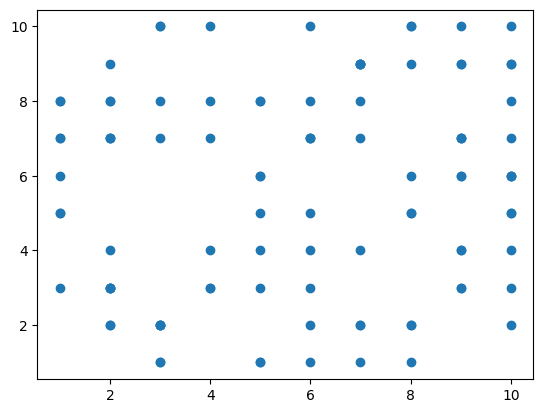

In [3]:
plt.scatter(x_vals,y_vals)

In [4]:
from shapely.geometry import Point, Polygon
poly_verts = [(3, 3), (7, 3), (8, 6), (5, 9), (6, 7)]
polygon = Polygon(poly_verts)

In [5]:
points = np.column_stack((x_vals, y_vals))
mask_list = []
for pt in points:
    point = Point(pt)
    if polygon.contains(point) or polygon.touches(point):
        mask_list.append(True)
    else:
        mask_list.append(False)

mask = np.array(mask_list)

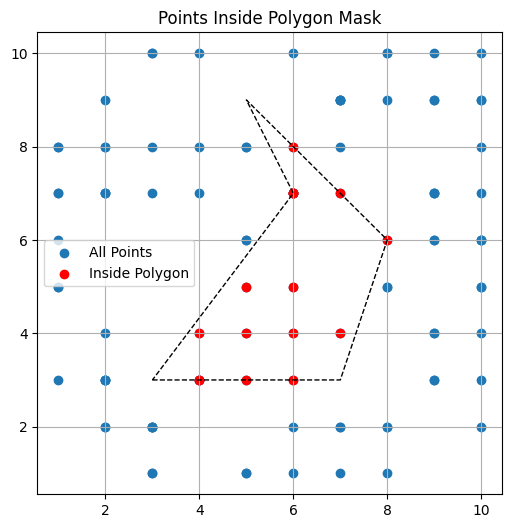

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(x_vals, y_vals, label='All Points')

plt.scatter(x_vals[mask], y_vals[mask], color='red', label='Inside Polygon')


# Draw polygon outline
poly_xs, poly_ys = zip(*poly_verts)
plt.plot(poly_xs + (poly_xs[0],), poly_ys + (poly_ys[0],), color='black', linewidth=1, linestyle='dashed')

plt.legend()
plt.title("Points Inside Polygon Mask")
plt.grid(True)
plt.show()


In [7]:
##trying to repeat the process for a subsection of ice sheet data
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# crs = ccrs.PlateCarree()
import warnings
warnings.filterwarnings('ignore')


In [8]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/Data/'
path_ds = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'

# ice_vel_ds = xr.open_dataset(path + 'ice_vels_no_nan_ds.nc')
ice_vels_ds_melt_and_mean = xr.open_dataset(path + 'ice_vels_ds_melt_and_mean.nc')
#dot_masked_ds = xr.open_dataset(path_ds + 'dot_masked.nc')
ssh_regridded_ds = xr.open_dataset(path + 'regridded_ssh2icevel_ds.nc')
ssh_regridded_flipped = ssh_regridded_ds['SSH_regridded'].isel(y=slice(None, None, -1))
oss_regridded_ds = xr.open_dataset(path + 'regridded_oss2icevel_ds.nc')
wsc_regridded_ds = xr.open_dataset(path + 'regridded_wsc2icevel_ds.nc')
bedmap3 = xr.open_dataset(path_ds + 'bedmap3.nc')

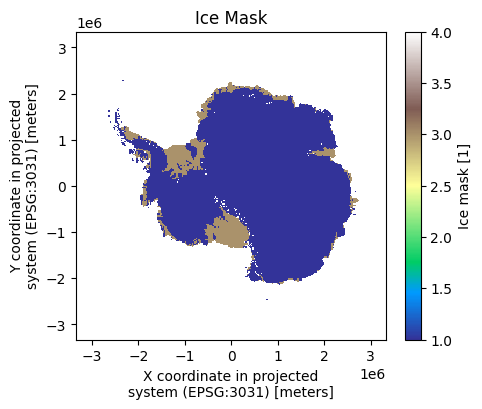

In [9]:
%matplotlib inline

# Subset or downsample (e.g., every 50th point)
bed = bedmap3['mask'][::50, ::50]

# Plot
plt.figure(figsize=(5, 4))
bed.plot(cmap='terrain')
plt.title('Ice Mask')
plt.show()


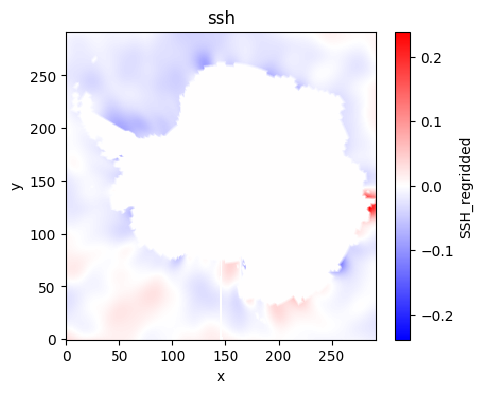

In [10]:
%matplotlib inline
# Flip the data vertically using isel (reverse y-axis index)
ssh_flipped = ssh_regridded_ds['SSH_regridded'].isel(time=6, y=slice(None, None, -1), x=slice(None, None, 10))[::10]
# Plot
plt.figure(figsize=(5, 4))
ssh_flipped.plot(cmap='bwr')

plt.title('ssh')
plt.show()


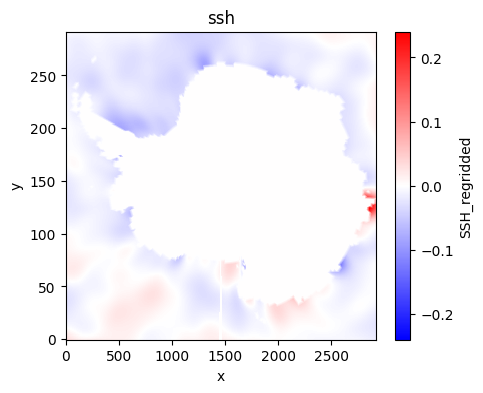

In [11]:
%matplotlib inline
# Flip the data vertically using isel (reverse y-axis index)
ssh_test = ssh_regridded_flipped.isel(time=6)[::10]
# Plot
plt.figure(figsize=(5, 4))
ssh_test.plot(cmap='bwr')

plt.title('ssh')
plt.show()

In [12]:
print(ssh_flipped.dims)
print(ssh_flipped.coords)

('y', 'x')
Coordinates:
    time     datetime64[ns] 8B 2004-03-01
    lat      (y, x) float64 682kB ...
    lon      (y, x) float64 682kB ...


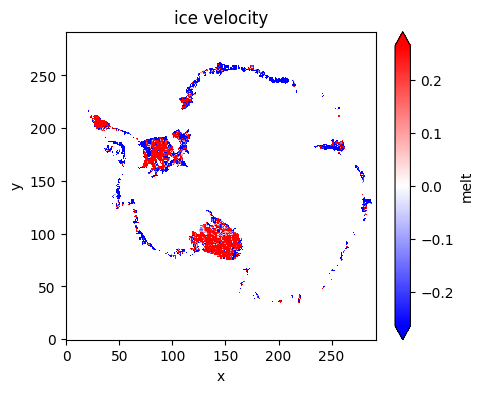

In [13]:
%matplotlib inline
# Subset or downsample (e.g., every 10th point)
# melt = ice_vels_ds_melt_and_mean['melt'].isel(time=6, x=slice(None, None, 10), y=slice(None, None, 10))
melt = ice_vels_ds_melt_and_mean['melt'][6, ::10, ::10]
# Plot
plt.figure(figsize=(5, 4))
melt.plot(cmap='bwr', robust = True)
plt.title('ice velocity')
plt.show()


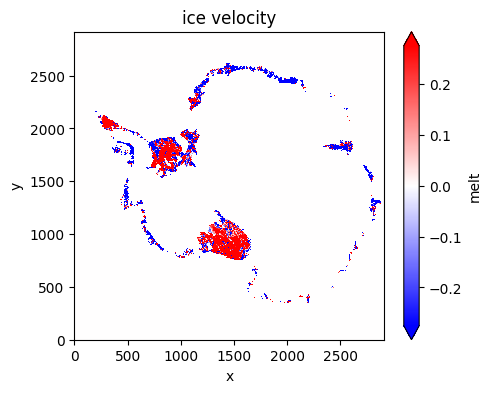

In [14]:
%matplotlib inline
# Subset or downsample (e.g., every 10th point)
# melt = ice_vels_ds_melt_and_mean['melt'].isel(time=6, x=slice(None, None, 10), y=slice(None, None, 10))
melt = ice_vels_ds_melt_and_mean['melt'][6, ::, ::]
# Plot
plt.figure(figsize=(5, 4))
melt.plot(cmap='bwr', robust = True)
plt.title('ice velocity')
plt.show()


In [15]:
print(ice_vels_ds_melt_and_mean['melt'].dims)
print(ice_vels_ds_melt_and_mean['melt'].coords)


('time', 'y', 'x')
Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
  * time     (time) datetime64[ns] 472B 2003-03-01 2003-06-01 ... 2017-09-01


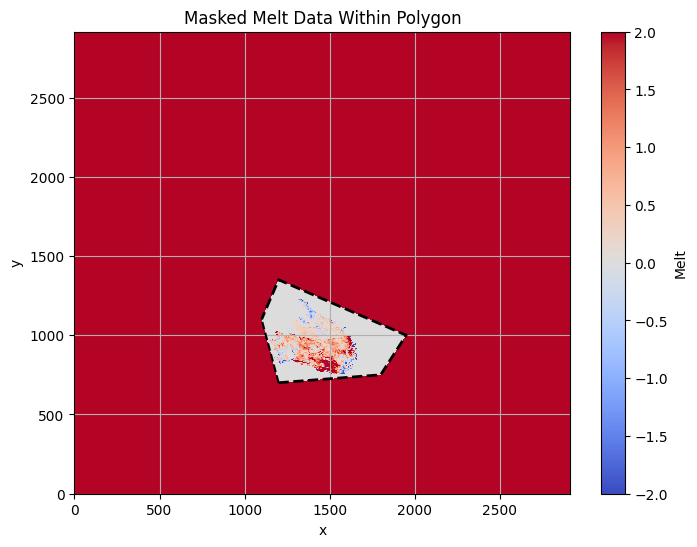

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from shapely.geometry import Polygon
from shapely import vectorized

# Load dataset (already loaded in your session, just referencing here)
# ice_vels_ds_melt_and_mean = xr.open_dataset('your_dataset.nc')

# Define your polygon vertices in the same coordinate system as x/y
poly_verts = [(1200, 700), (1800, 750), (1950, 1000), (1200, 1350), (1100, 1100)]
polygon = Polygon(poly_verts)

# Get x and y coordinate arrays
x_vals = ice_vels_ds_melt_and_mean['x'].values
y_vals = ice_vels_ds_melt_and_mean['y'].values

# Downsample if needed (e.g., every 10th point)
x_vals_ds = x_vals
y_vals_ds = y_vals

# Create meshgrid
X, Y = np.meshgrid(x_vals_ds, y_vals_ds)

# Apply vectorized shapely mask: True if inside or on polygon boundary
mask = vectorized.contains(polygon, X, Y) | vectorized.touches(polygon, X, Y)

# Subset melt data accordingly
melt_data = ice_vels_ds_melt_and_mean['melt'].isel(time=6)
melt_ds = melt_data  # downsampled to match X/Y shape

# Mask the melt data
melt_masked = np.where(mask, melt_ds, 2)
# melt_masked = np.where(melt_ds, mask, 2)

# Plot
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, melt_masked, cmap='coolwarm', shading='auto')
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')  # close polygon
melt.plot

plt.title('Masked Melt Data Within Polygon')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Melt')
plt.clim(-2,2)
plt.grid(True)
plt.show()


In [17]:
# melt_masked_nan = np.where(melt_masked ==2, np.nan, melt_masked)
# melt_masked_clean = np.where(melt_masked_nan ==0, np.nan, melt_masked_nan)

In [18]:
melt_masked_clean = np.where((melt_masked == 2) | (melt_masked == 0), np.nan, melt_masked)

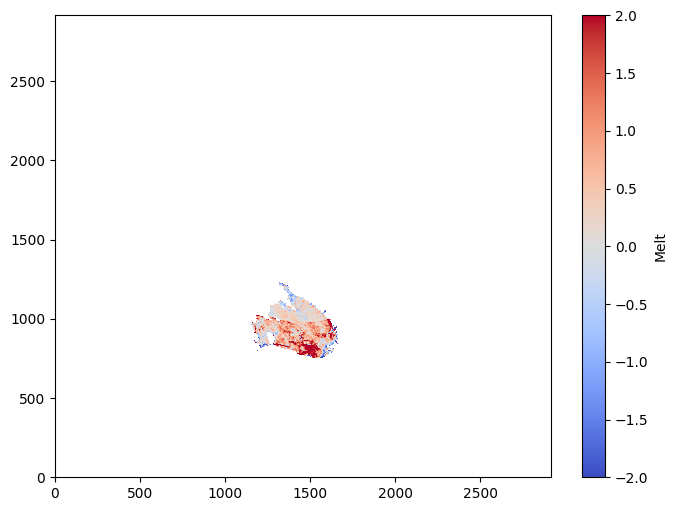

In [19]:
# plt.figure(figsize=(8, 6))
# plt.pcolormesh(X, Y, melt_masked_nan, cmap='coolwarm', shading='auto')
# plt.colorbar(label='Melt')
# plt.clim(-2,2)

plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, melt_masked_clean, cmap='coolwarm', shading='auto')
plt.colorbar(label='Melt')
plt.clim(-2,2)

In [20]:
melt_mean = np.nanmean(melt_masked_clean)
print("Mean (excluding NaNs):", melt_mean)

# melt_masked_mean = np.where(~np.isnan(melt_masked_nan), melt_mean, melt_masked_nan)



Mean (excluding NaNs): 0.50634223


In [21]:
#finding the average for all times
import numpy as np
import xarray as xr
from shapely.geometry import Polygon
from shapely import vectorized

# Define polygon
poly_verts = [(1200, 700), (1800, 750), (1950, 1000), (1200, 1350), (1100, 1100)]
polygon = Polygon(poly_verts)

# Get x and y coordinate arrays
x_vals = ice_vels_ds_melt_and_mean['x'].values
y_vals = ice_vels_ds_melt_and_mean['y'].values

# Create meshgrid (same for all time steps)
X, Y = np.meshgrid(x_vals, y_vals)

# Compute 2D polygon mask (True inside polygon, False outside)
mask_2d = vectorized.contains(polygon, X, Y) | vectorized.touches(polygon, X, Y)

# Broadcast mask to match (time, y, x) shape
mask_3d = np.broadcast_to(mask_2d, ice_vels_ds_melt_and_mean['melt'].shape)

# Get melt data (3D: time, y, x)
melt_all = ice_vels_ds_melt_and_mean['melt']

# Step 1: Apply polygon mask — keep values inside polygon, set others to 2
melt_masked = xr.where(mask_3d, melt_all, 2)

# Step 2: Apply your logic:
# Set to NaN wherever value == 2 (outside polygon) OR == 0 (invalid melt value)
melt_masked_clean = xr.where((melt_masked == 2) | (melt_masked == 0), np.nan, melt_masked)

# Step 3: Compute mean melt inside the polygon at each time step
mean_melt_timeseries = melt_masked_clean.mean(dim=('y', 'x'), skipna=True)

# Now you can use this for time series analysis or regression
print(mean_melt_timeseries)


<xarray.DataArray 'melt' (time: 59)> Size: 236B
array([ 0.22429122, -0.16452679, -0.4979981 , -0.60628414, -0.3797633 ,
        0.06178179,  0.50634223,  0.6651487 ,  0.40305135, -0.02850104,
       -0.23026778, -0.2057636 , -0.26739007, -0.3951854 , -0.3280046 ,
        0.0765091 ,  0.43573388,  0.46800566,  0.21741624, -0.02391738,
       -0.16221155, -0.25407994, -0.33895618, -0.42528072, -0.34505922,
       -0.10047732,  0.26164833,  0.5126847 ,  0.4591658 ,  0.23317438,
        0.02643075, -0.04350505, -0.06718785, -0.02111369,  0.02418488,
        0.09612554,  0.06721242, -0.07980304, -0.14293271, -0.1478656 ,
       -0.16207184, -0.27747333, -0.38298887, -0.25583032, -0.11243607,
        0.03109923,  0.01536545, -0.12080618, -0.22784126, -0.13392201,
        0.17920268,  0.48480254,  0.57383823,  0.43537942,  0.1563468 ,
       -0.07774591, -0.14922225, -0.18881564, -0.11510672], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 472B 2003-03-01 2003-06-01 ... 2017-0

In [22]:
print(mean_melt_timeseries.shape)
print(mean_melt_timeseries.dtype)

(59,)
float32


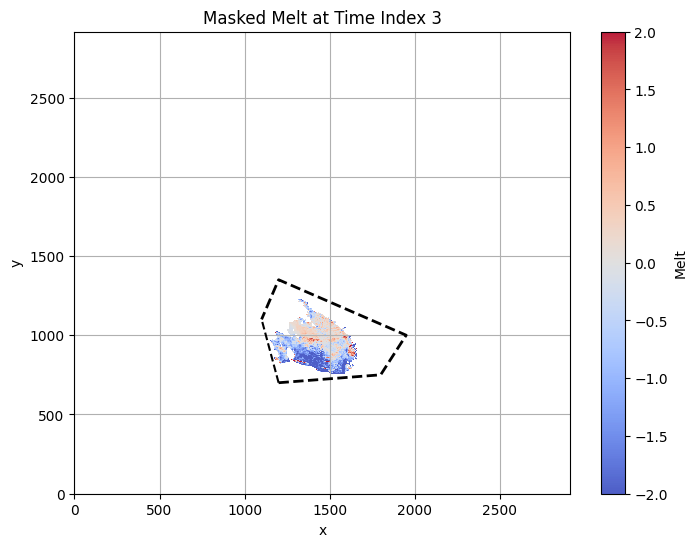

In [23]:
# --- Plotting a single timestep from the cleaned array ---
t_index = 3  # for example
clean_melt_at_t = melt_masked_clean.isel(time=t_index).values

plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, clean_melt_at_t, cmap='coolwarm', shading='auto', alpha=0.9)
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')  # close polygon
plt.colorbar(label='Melt')
plt.clim(-2, 2)
plt.title(f'Masked Melt at Time Index {t_index}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

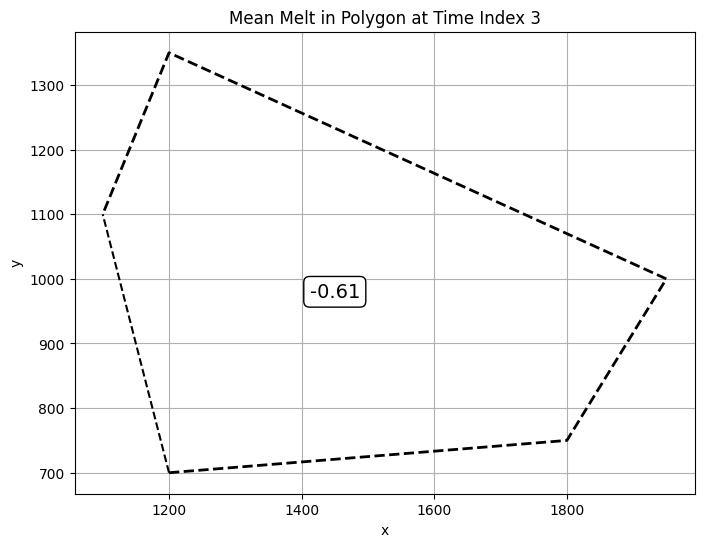

In [24]:
mean_val = mean_melt_timeseries[t_index].values
cx = np.mean([v[0] for v in poly_verts])
cy = np.mean([v[1] for v in poly_verts])

plt.figure(figsize=(8, 6))
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')

plt.text(cx, cy, f'{mean_val:.2f}', fontsize=14, ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white'))

plt.title(f'Mean Melt in Polygon at Time Index {t_index}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


In [25]:
print(mean_melt_timeseries.dtype)

float32


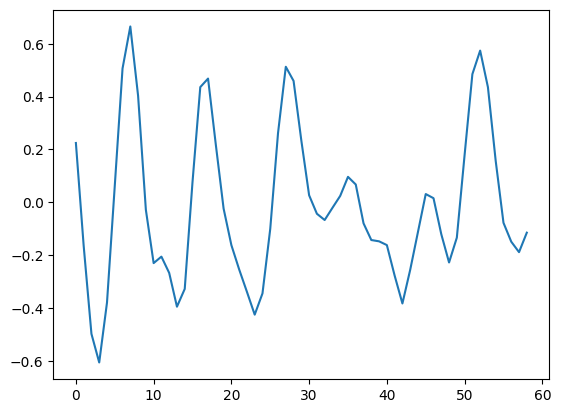

In [26]:
plt.plot(mean_melt_timeseries)

new coords:  1200 500


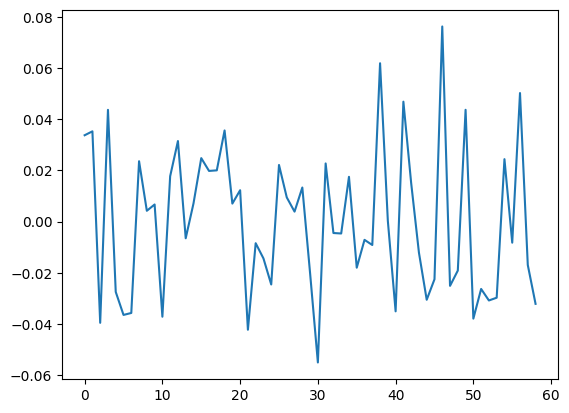

In [27]:
target_x = 1200
target_y = 500

# x_vals and y_vals are 1D arrays
ix = np.argmin(np.abs(x_vals - target_x))
iy = np.argmin(np.abs(y_vals - target_y))
print('new coords: ', ix, iy)

plt.plot(ssh_regridded_flipped[2:,ix, iy])

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# x = indep
# y = dep

x = (ssh_regridded_flipped[2:,1200,500]).values
x = x.reshape(-1, 1)
y = mean_melt_timeseries.values

reg = LinearRegression().fit(x,y)

y_pred = reg.predict(x)


print('coefficients:',reg.coef_)
print('mean squared error', mean_squared_error(y, y_pred))
print('variance score: %2f', r2_score(y, y_pred))


coefficients: [-0.12602087]
mean squared error 0.08589045311405123
variance score: %2f 0.0001568182206620472


In [41]:
print("Min SSH:", np.nanmin(x))
print("Max SSH:", np.nanmax(x))
print("Std SSH:", np.nanstd(x))

Min SSH: -0.05511001385216163
Max SSH: 0.07631677998531756
Std SSH: 0.02912475449083245


In [42]:
x_raw = ssh_regridded_flipped[2:, ix,iy].values  # shape: (time,)
print("Before reshape:", x_raw.shape, "Example values:", x_raw[:5])

x = x_raw.reshape(-1, 1)
print("After reshape:", x.shape, "Example reshaped values:", x[:5])


Before reshape: (59,) Example values: [ 0.03377003  0.03530381 -0.03959737  0.04370856 -0.02751291]
After reshape: (59, 1) Example reshaped values: [[ 0.03377003]
 [ 0.03530381]
 [-0.03959737]
 [ 0.04370856]
 [-0.02751291]]


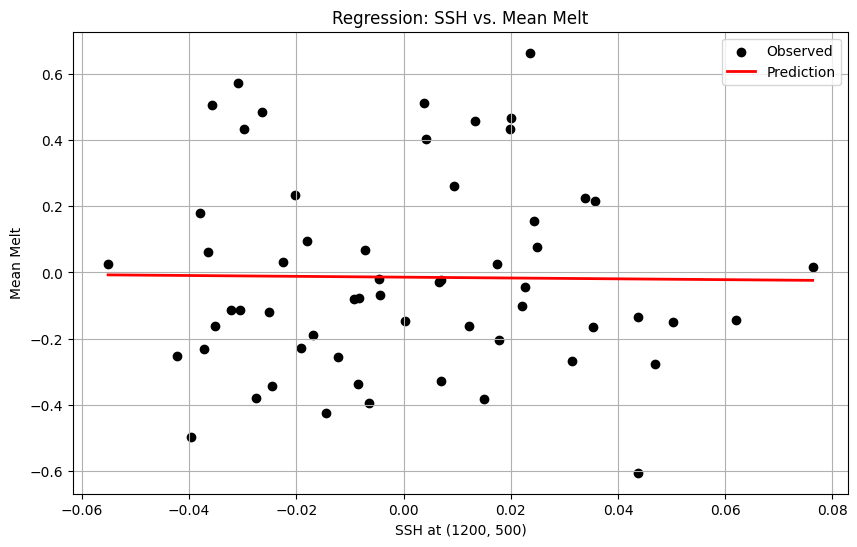

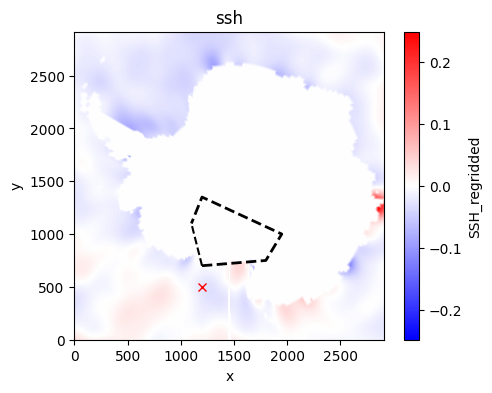

In [48]:
import numpy as np

# Sort x and y_pred for clean line plotting
sorted_indices = np.argsort(x[:, 0])  # x is 2D: shape (time, 1)
x_sorted = x[sorted_indices]
y_sorted = y[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Now plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Observed')
plt.plot(x_sorted, y_pred_sorted, color='red', linewidth=2, label='Prediction')
plt.xlabel(f'SSH at {ix, iy}')
plt.ylabel('Mean Melt')
plt.title('Regression: SSH vs. Mean Melt')
plt.legend()
plt.grid(True)
plt.show()

# Flip the data vertically using isel (reverse y-axis index)
ssh_flipped = ssh_regridded_flipped.isel(time=6)
# Plot
plt.figure(figsize=(5, 4))
ssh_flipped.plot(cmap='bwr')
plt.plot(ix,iy, color='red', marker='x' )
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')

plt.title('ssh')
plt.show()


In [51]:
from scipy.stats import pearsonr, spearmanr

x = (ssh_regridded_flipped[2:, 1200, 500]).values
y = mean_melt_timeseries.values

# Remove NaNs
mask = ~np.isnan(x) & ~np.isnan(y)
corr = np.corrcoef(x[mask], y[mask])[0, 1]

# Pearson
corr_p, pval_p = pearsonr(x[mask], y[mask])
print(f"Pearson r = {corr_p:.3f}, p = {pval_p:.3g}")

# Spearman (optional)
corr_s, pval_s = spearmanr(x[mask], y[mask])
print(f"Spearman r = {corr_s:.3f}, p = {pval_s:.3g}")



Pearson r = -0.013, p = 0.925
Spearman r = 0.015, p = 0.909


In [31]:
stop

NameError: name 'stop' is not defined

In [29]:
from regression_izzyv1 import linregress_3D_spatial_time

ssh = ssh_regridded_flipped[2:]
n, slope, intercept, p_val, r_sq, rmse = linregress_3D_spatial_time(
    y_array=ssh.values,
    x_series=mean_melt_timeseries.values
)



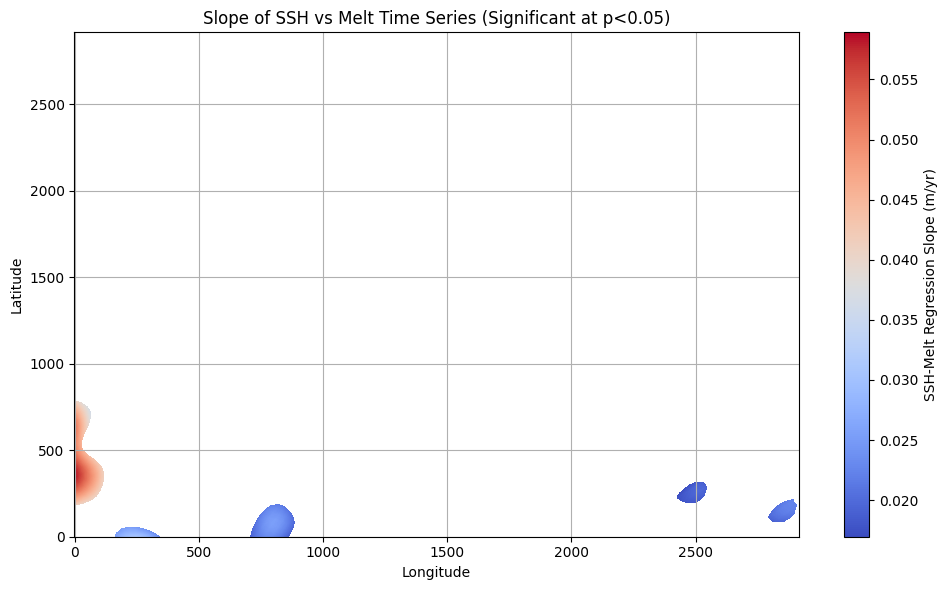

In [30]:

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Assume ssh = ssh_regridded_flipped[2:] is a DataArray with dims (time, y, x)
# Grab coordinate grids (assuming 2D, shape matches slope)
lon = ssh_regridded_flipped['x']
lat = ssh_regridded_flipped['y']

# Optional: mask slope where p > 0.05 (not significant)
significant_mask = p_val < 0.05
slope_sig = np.where(significant_mask, slope, np.nan)

# Plot slope
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon, lat, slope_sig, cmap='coolwarm', shading='auto')
plt.colorbar(label='SSH-Melt Regression Slope (m/yr)')
plt.title('Slope of SSH vs Melt Time Series (Significant at p<0.05)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


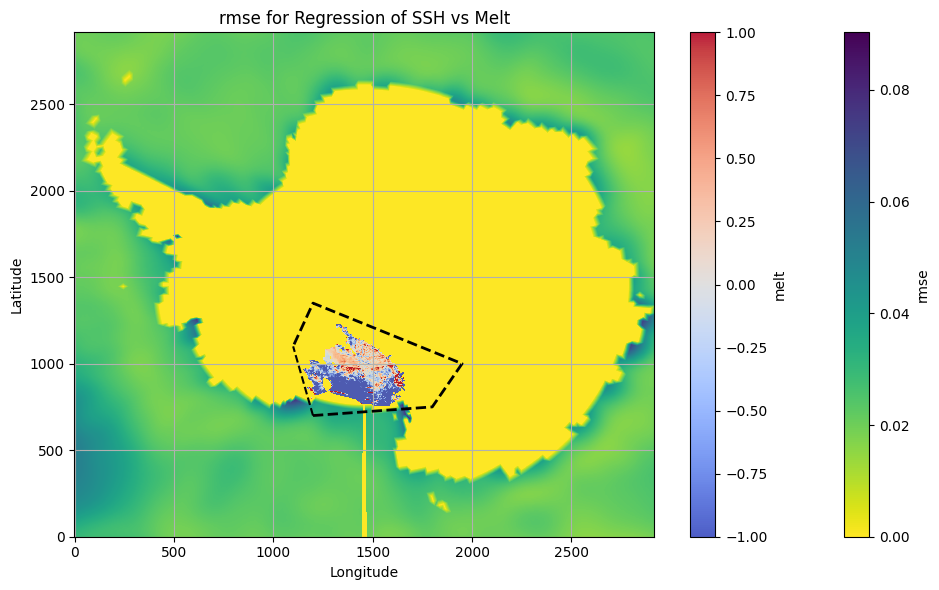

In [31]:
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon, lat, rmse, cmap='viridis_r', shading='auto')
plt.colorbar(label='rmse')
plt.pcolormesh(X, Y, clean_melt_at_t, cmap='coolwarm', shading='auto', alpha=0.9, vmin = -1, vmax = 1)
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')  # close polygon
plt.colorbar(label='melt')
plt.title('rmse for Regression of SSH vs Melt')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


In [32]:
"""

NEED TO CHANGE THE FUNCTION IN REGRESSION TO INCLUDE THE AREA/LOCATION OF THE TIME SERIES AS CURRENTLY JUST LOOKING AT ALL SSH VS THIS TIME SERIES (WITHOUT LOCATION OF ICE SHEET CONSIDERED) xx

"""

'\n\nNEED TO CHANGE THE FUNCTION IN REGRESSION TO INCLUDE THE AREA/LOCATION OF THE TIME SERIES AS CURRENTLY JUST LOOKING AT ALL SSH VS THIS TIME SERIES (WITHOUT LOCATION OF ICE SHEET CONSIDERED) xx\n\n'

In [33]:
""""
second test poly verts defined - this area is Ronne IS
"""

'"\nsecond test poly verts defined - this area is Ronne IS\n'

In [34]:
x_vals = ice_vels_ds_melt_and_mean['x'].values
y_vals = ice_vels_ds_melt_and_mean['y'].values

# Downsample if needed (e.g., every 10th point)
x_vals_ds = x_vals
y_vals_ds = y_vals

# Create meshgrid
X, Y = np.meshgrid(x_vals_ds, y_vals_ds)

print(x_vals.shape)
print(y_vals.shape)

(2916,)
(2916,)


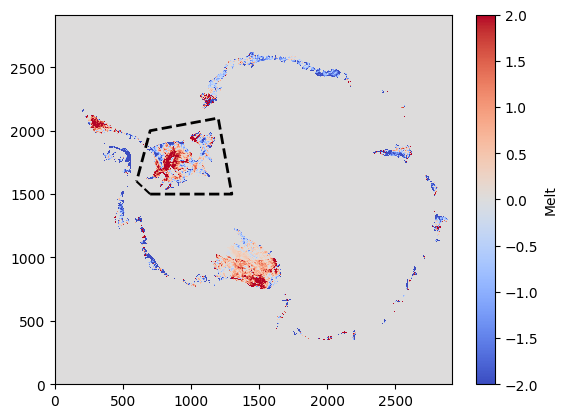

In [35]:
#trying to create a polygon and overlaying this on ice melt data
from shapely.geometry import Point, Polygon

poly_verts_test = [(700,1500), (1300, 1500), (1200, 2100), (700, 2000), (600, 1600)]
polygon = Polygon(poly_verts_test)

melt_data = ice_vels_ds_melt_and_mean['melt'].isel(time=6)

plt.pcolormesh(X, Y, melt_data, cmap='coolwarm', shading='auto')
plt.plot(*zip(*poly_verts_test), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts_test[0][0], poly_verts_test[-1][0]],
         [poly_verts_test[0][1], poly_verts_test[-1][1]], '--', color='black')
plt.colorbar(label='Melt')
plt.clim(-2,2)


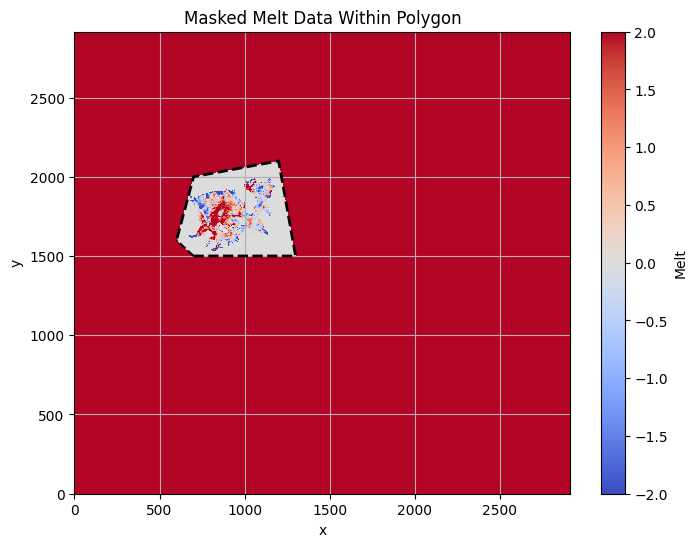

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from shapely.geometry import Polygon
from shapely import vectorized

# Load dataset (already loaded in your session, just referencing here)
# ice_vels_ds_melt_and_mean = xr.open_dataset('your_dataset.nc')

# Define your polygon vertices in the same coordinate system as x/y
poly_verts = poly_verts_test
polygon = Polygon(poly_verts)

# Get x and y coordinate arrays
x_vals = ice_vels_ds_melt_and_mean['x'].values
y_vals = ice_vels_ds_melt_and_mean['y'].values

# Downsample if needed (e.g., every 10th point)
x_vals_ds = x_vals
y_vals_ds = y_vals

# Create meshgrid
X, Y = np.meshgrid(x_vals_ds, y_vals_ds)

# Apply vectorized shapely mask: True if inside or on polygon boundary
mask = vectorized.contains(polygon, X, Y) | vectorized.touches(polygon, X, Y)

# Subset melt data accordingly
melt_data = ice_vels_ds_melt_and_mean['melt'].isel(time=6)
melt_ds = melt_data  # downsampled to match X/Y shape

# Mask the melt data
melt_masked = np.where(mask, melt_ds, 2)
# melt_masked = np.where(melt_ds, mask, 2)

# Plot
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, melt_masked, cmap='coolwarm', shading='auto')
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')  # close polygon
melt.plot

plt.title('Masked Melt Data Within Polygon')
plt.xlabel('x')
plt.ylabel('y')
plt.colorbar(label='Melt')
plt.clim(-2,2)
plt.grid(True)
plt.show()


In [37]:
melt_masked_clean = np.where((melt_masked == 2) | (melt_masked == 0), np.nan, melt_masked)

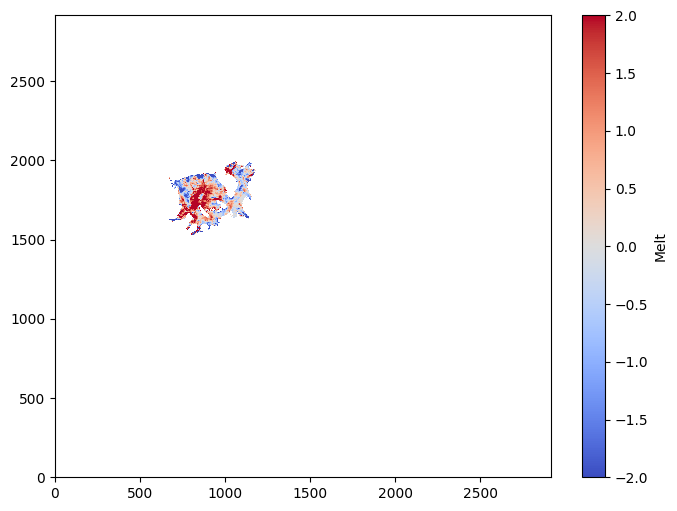

In [38]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, melt_masked_clean, cmap='coolwarm', shading='auto')
plt.colorbar(label='Melt')
plt.clim(-2,2)

In [39]:
melt_mean = np.nanmean(melt_masked_clean)
print("Mean (excluding NaNs):", melt_mean)

# melt_masked_mean = np.where(~np.isnan(melt_masked_nan), melt_mean, melt_masked_nan)



Mean (excluding NaNs): 0.23890576


In [40]:
#finding the average for all times
import numpy as np
import xarray as xr
from shapely.geometry import Polygon
from shapely import vectorized

# Define polygon
poly_verts = poly_verts_test
polygon = Polygon(poly_verts)

# Get x and y coordinate arrays
x_vals = ice_vels_ds_melt_and_mean['x'].values
y_vals = ice_vels_ds_melt_and_mean['y'].values

# Create meshgrid (same for all time steps)
X, Y = np.meshgrid(x_vals, y_vals)

# Compute 2D polygon mask (True inside polygon, False outside)
mask_2d = vectorized.contains(polygon, X, Y) | vectorized.touches(polygon, X, Y)

# Broadcast mask to match (time, y, x) shape
mask_3d = np.broadcast_to(mask_2d, ice_vels_ds_melt_and_mean['melt'].shape)

# Get melt data (3D: time, y, x)
melt_all = ice_vels_ds_melt_and_mean['melt']

# Step 1: Apply polygon mask — keep values inside polygon, set others to 2
melt_masked = xr.where(mask_3d, melt_all, 2)

# Step 2: Apply your logic:
# Set to NaN wherever value == 2 (outside polygon) OR == 0 (invalid melt value)
melt_masked_clean = xr.where((melt_masked == 2) | (melt_masked == 0), np.nan, melt_masked)

# Step 3: Compute mean melt inside the polygon at each time step
mean_melt_timeseries = melt_masked_clean.mean(dim=('y', 'x'), skipna=True)

# Now you can use this for time series analysis or regression
print(mean_melt_timeseries)


<xarray.DataArray 'melt' (time: 59)> Size: 236B
array([-0.7445288 , -1.3338767 , -1.6298808 , -1.7942343 , -1.669974  ,
       -0.9227951 ,  0.23890573,  1.018698  ,  0.9698909 ,  0.617506  ,
        0.2822334 ,  0.03897838, -0.22628933, -0.1113143 ,  0.46727335,
        0.83742785,  0.42226627, -0.32523897, -0.76679826, -0.8143961 ,
       -0.86138487, -0.88741404, -0.63892937, -0.18115348,  0.17777051,
        0.26429802,  0.08588257, -0.3873513 , -0.8461307 , -0.8535315 ,
       -0.15072335,  0.6334645 ,  0.6393707 ,  0.20999028, -0.23800524,
       -0.35534695, -0.34601095, -0.43644676, -0.21717891,  0.01824116,
        0.00593928, -0.44879773, -1.2964673 , -1.7483712 , -1.4694403 ,
       -0.65640134,  0.23821083,  0.7202088 ,  0.69894785,  0.4716778 ,
        0.07274683, -0.29217085, -0.43655577, -0.34380788, -0.09621956,
       -0.03250597, -0.1466041 , -0.19117232, -0.18865499], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 472B 2003-03-01 2003-06-01 ... 2017-0

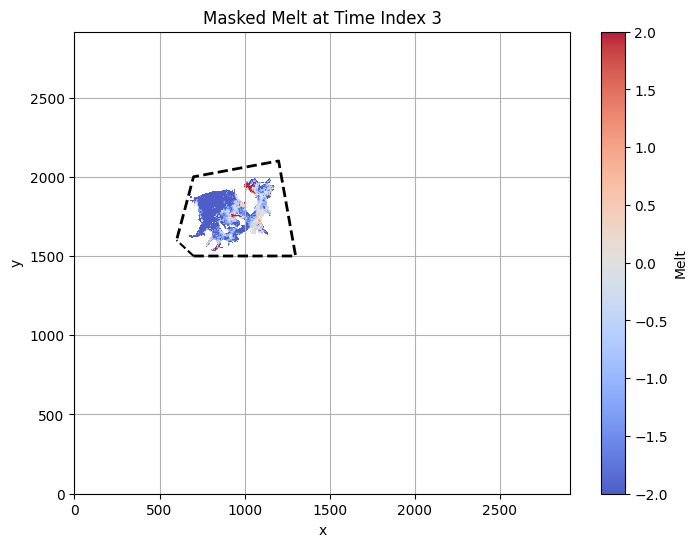

In [41]:
# --- Plotting a single timestep from the cleaned array ---
t_index = 3  # for example
clean_melt_at_t = melt_masked_clean.isel(time=t_index).values

plt.figure(figsize=(8, 6))
plt.pcolormesh(X, Y, clean_melt_at_t, cmap='coolwarm', shading='auto', alpha=0.9)
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')  # close polygon
plt.colorbar(label='Melt')
plt.clim(-2, 2)
plt.title(f'Masked Melt at Time Index {t_index}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

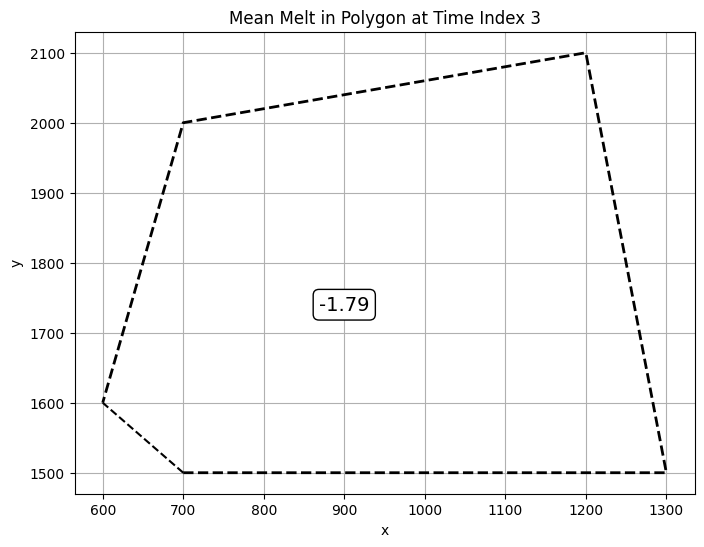

In [42]:
mean_val = mean_melt_timeseries[t_index].values
cx = np.mean([v[0] for v in poly_verts])
cy = np.mean([v[1] for v in poly_verts])

plt.figure(figsize=(8, 6))
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')

plt.text(cx, cy, f'{mean_val:.2f}', fontsize=14, ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white'))

plt.title(f'Mean Melt in Polygon at Time Index {t_index}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


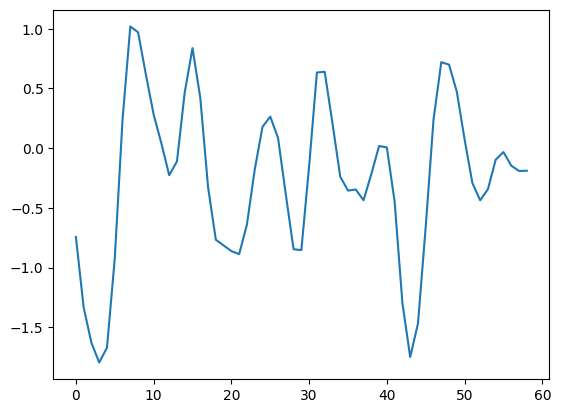

In [43]:
plt.plot(mean_melt_timeseries)

In [44]:
from regression_izzyv1 import linregress_3D_spatial_time

ssh = ssh_regridded_flipped[2:]
n, slope, intercept, p_val, r_sq, rmse = linregress_3D_spatial_time(
    y_array=ssh.values,
    x_series=mean_melt_timeseries.values
)

from regression_izzyv1 import linregress_1D_on_3D
ssh = ssh_regridded_flipped[2:]
n_2, slope_2, intercept_2, p_val_2, r_sq_2, rmse_2 = linregress_1D_on_3D(
    x_array=ssh.values,
    y_series=mean_melt_timeseries.values
)


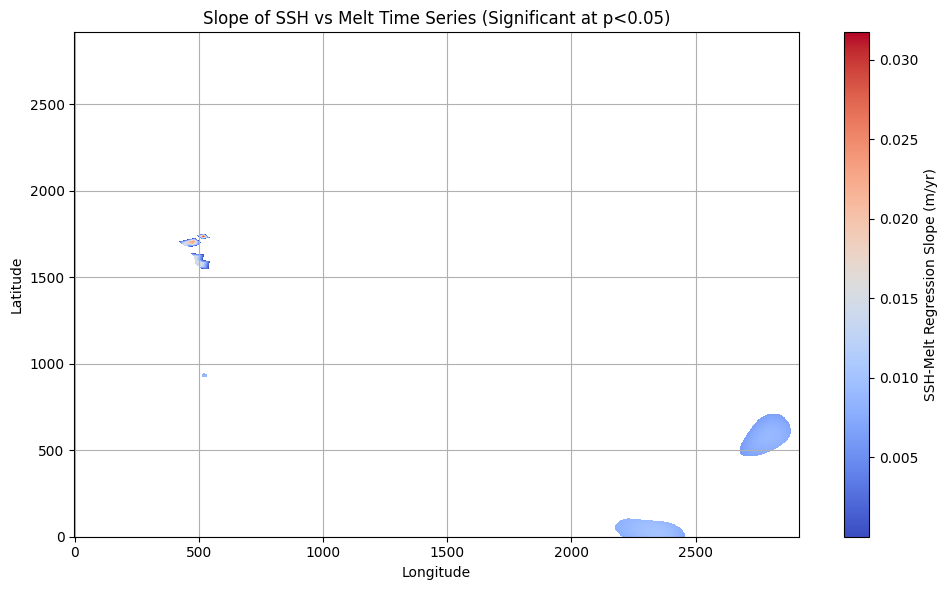

In [45]:

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Assume ssh = ssh_regridded_flipped[2:] is a DataArray with dims (time, y, x)
# Grab coordinate grids (assuming 2D, shape matches slope)
lon = ssh_regridded_flipped['x']
lat = ssh_regridded_flipped['y']

# Optional: mask slope where p > 0.05 (not significant)
significant_mask = p_val < 0.05
slope_sig = np.where(significant_mask, slope, np.nan)

# Plot slope
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon, lat, slope_sig, cmap='coolwarm', shading='auto')
plt.colorbar(label='SSH-Melt Regression Slope (m/yr)')
plt.title('Slope of SSH vs Melt Time Series (Significant at p<0.05)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


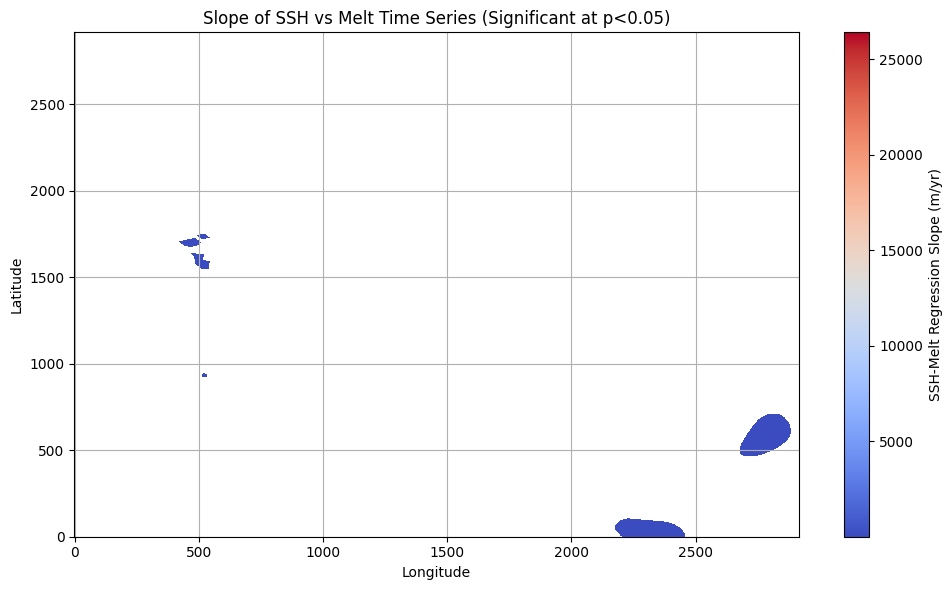

In [46]:

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# Assume ssh = ssh_regridded_flipped[2:] is a DataArray with dims (time, y, x)
# Grab coordinate grids (assuming 2D, shape matches slope)
lon = ssh_regridded_flipped['x']
lat = ssh_regridded_flipped['y']

# Optional: mask slope where p > 0.05 (not significant)
significant_mask = p_val_2 < 0.05
slope_sig = np.where(significant_mask, slope_2, np.nan)

# Plot slope
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon, lat, slope_sig, cmap='coolwarm', shading='auto')
plt.colorbar(label='SSH-Melt Regression Slope (m/yr)')
plt.title('Slope of SSH vs Melt Time Series (Significant at p<0.05)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


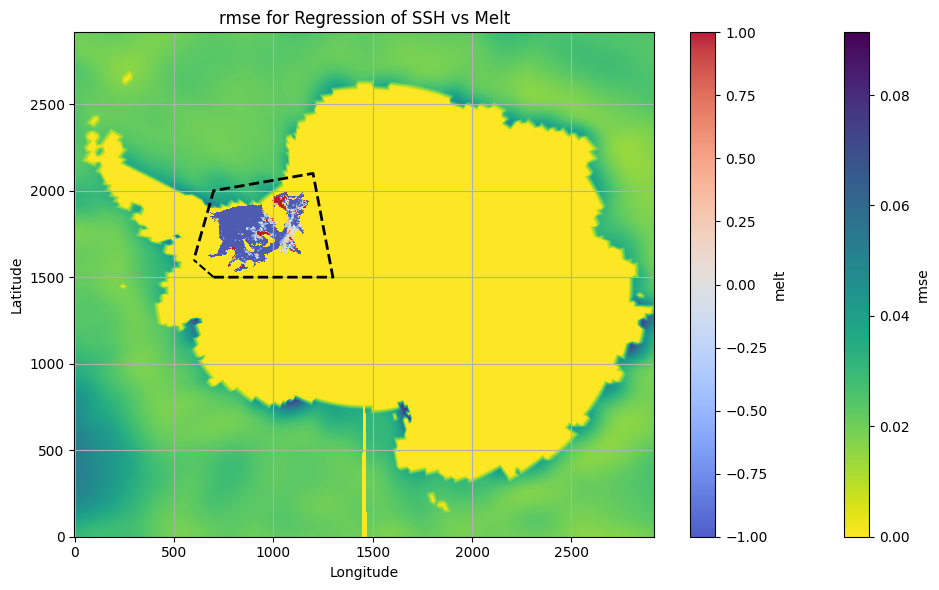

In [47]:
plt.figure(figsize=(10, 6))
plt.pcolormesh(lon, lat, rmse, cmap='viridis_r', shading='auto')
plt.colorbar(label='rmse')
plt.pcolormesh(X, Y, clean_melt_at_t, cmap='coolwarm', shading='auto', alpha=0.9, vmin = -1, vmax = 1)
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')  # close polygon
plt.colorbar(label='melt')
plt.title('rmse for Regression of SSH vs Melt')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()


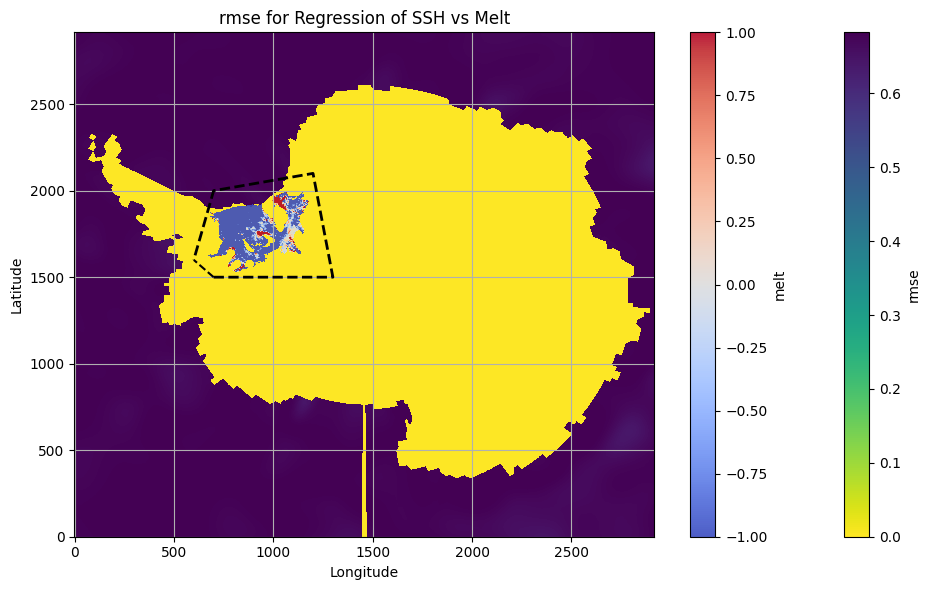

In [48]:

plt.figure(figsize=(10, 6))
plt.pcolormesh(lon, lat, rmse_2, cmap='viridis_r', shading='auto')
plt.colorbar(label='rmse')
plt.pcolormesh(X, Y, clean_melt_at_t, cmap='coolwarm', shading='auto', alpha=0.9, vmin=-1, vmax=1)
plt.plot(*zip(*poly_verts), linestyle='--', color='black', linewidth=2)
plt.plot([poly_verts[0][0], poly_verts[-1][0]],
         [poly_verts[0][1], poly_verts[-1][1]], '--', color='black')  # close polygon
plt.colorbar(label='melt')
plt.title('rmse for Regression of SSH vs Melt')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
stop

NameError: name 'stop' is not defined

In [50]:
"""
testing linear regression of one ocean point and one ice sheet average
"""

'\ntesting linear regression of one ocean point and one ice sheet average\n'

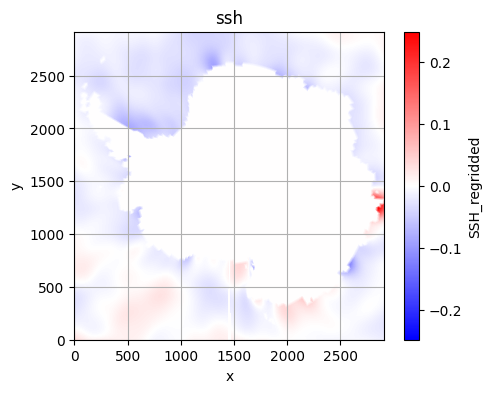

In [69]:

# Flip the data vertically using isel (reverse y-axis index)
ssh_test = ssh_regridded_flipped.isel(time=6)
# Plot
plt.figure(figsize=(5, 4))
ssh_test.plot(cmap='bwr')
plt.grid(True)

plt.title('ssh')
plt.show()

new coords:  500 2050


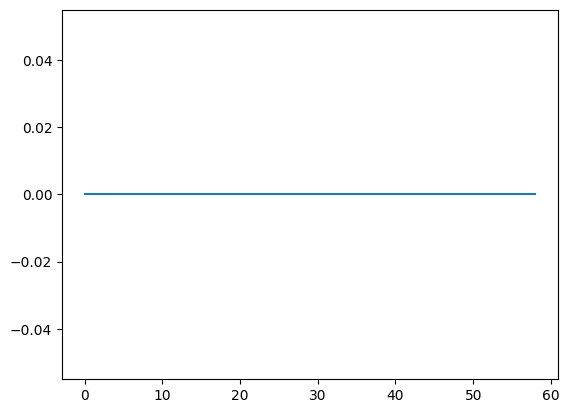

In [70]:
target_x = 500
target_y = 2050

# x_vals and y_vals are 1D arrays
ix = np.argmin(np.abs(x_vals - target_x))
iy = np.argmin(np.abs(y_vals - target_y))
print('new coords: ', ix, iy)

plt.plot(ssh_regridded_flipped[2:,ix, iy])

coefficients: [0.]
mean squared error 0.4658532911916992
variance score: %2f 0.0


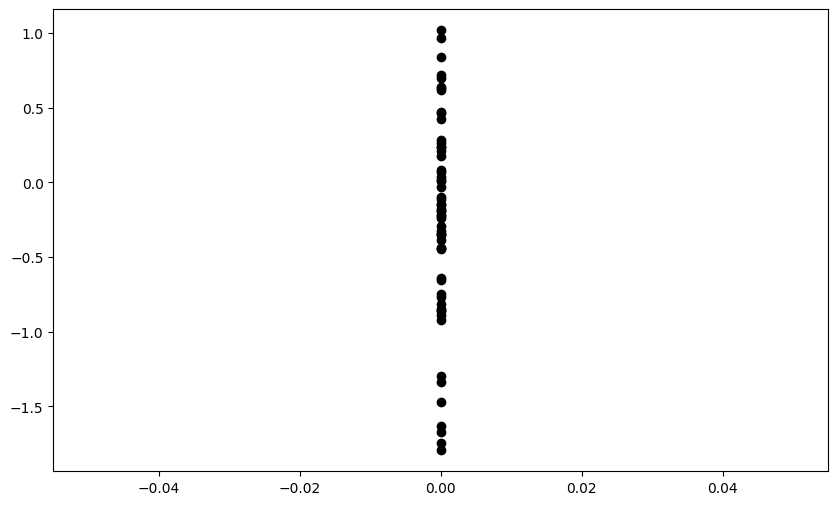

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# x = indep
# y = dep

x = (ssh_regridded_flipped[2:,750,2000]).values
x = x.reshape(-1, 1)
y = mean_melt_timeseries.values

reg = LinearRegression().fit(x,y)

y_pred = reg.predict(x)


print('coefficients:',reg.coef_)
print('mean squared error', mean_squared_error(y, y_pred))
print('variance score: %2f', r2_score(y, y_pred))

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black')
plt.plot(x, y_pred, color='red', linewidth = 3)
plt.xticks()
plt.yticks()
plt.show()




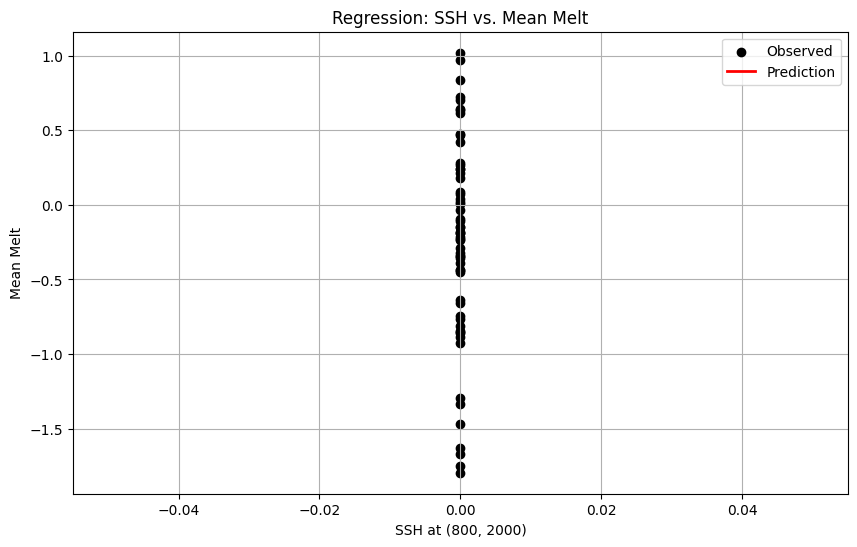

In [70]:
import numpy as np

# Sort x and y_pred for clean line plotting
sorted_indices = np.argsort(x[:, 0])  # x is 2D: shape (time, 1)
x_sorted = x[sorted_indices]
y_sorted = y[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Now plot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Observed')
plt.plot(x_sorted, y_pred_sorted, color='red', linewidth=2, label='Prediction')
plt.xlabel('SSH at (800, 2000)')
plt.ylabel('Mean Melt')
plt.title('Regression: SSH vs. Mean Melt')
plt.legend()
plt.grid(True)
plt.show()


In [71]:
print("Min SSH:", np.nanmin(x))
print("Max SSH:", np.nanmax(x))
print("Std SSH:", np.nanstd(x))


Min SSH: 0.0
Max SSH: 0.0
Std SSH: 0.0
